Weather Conditions Predictor🌦️

**Author:** _Gloria Ighagbon
**Email:** _gloriaewere@gmail.com_  
**Date:** October 28, 2025



## 1) Setup & Config

In [26]:
import os

# === Configuration ===
DATA_PATH = "local_weather (1).csv"    # Your uploaded file; consider renaming it to 'local_weather.csv'
TARGET_COL = "Condition"               # We'll create this below if it doesn't exist
DATE_COL = "DATE"                      # NOAA datasets commonly have a DATE column

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_JOBS = -1

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Using:", DATA_PATH)


Using: local_weather (1).csv


## 2) Imports

In [27]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
pd.set_option('display.max_columns', 100)

## 3) Load Data

In [28]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head(5))
print("\nColumns:", df.columns.tolist())

Shape: (16859, 36)


,STATION,NAME,DATE,ACMH,ACSH,AWND,DAPR,FMTM,FRGT,MDPR,PGTM,PRCP,SNOW,SNWD,TAVG,TMAX,TMIN,TSUN,WDF1,WDF2,WDF5,WDFG,WSF1,WSF2,WSF5,WSFG,WT01,WT02,WT03,WT04,WT05,WT07,WT08,WT09,WT16,WT18
0,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",1960-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,49.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",1960-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,49.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",1960-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,54.0,35.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",1960-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,54.0,36.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,USW00023230,"OAKLAND INTERNATIONAL AIRPORT, CA US",1960-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,NaN,55.0,33.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN



Columns: ['STATION', 'NAME', 'DATE', 'ACMH', 'ACSH', 'AWND', 'DAPR', 'FMTM', 'FRGT', 'MDPR', 'PGTM', 'PRCP', 'SNOW', 'SNWD', 'TAVG', 'TMAX', 'TMIN', 'TSUN', 'WDF1', 'WDF2', 'WDF5', 'WDFG', 'WSF1', 'WSF2', 'WSF5', 'WSFG', 'WT01', 'WT02', 'WT03', 'WT04', 'WT05', 'WT07', 'WT08', 'WT09', 'WT16', 'WT18']


## 4) Create a Simple `Condition` Label (if missing)

If there's no ready-made *condition* column, we make one using **very simple rules**:

- If `SNOW > 0` → `"Snowy"`  
- Else if `PRCP > 0` → `"Rainy"`  
- Else → `"Dry"`

> This keeps things kid-friendly and good enough for a class demo.


In [29]:
if "Condition" not in df.columns:
    # Fill missing numeric values temporarily for rule checks
    for col in ["SNOW", "PRCP"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)
        else:
            df[col] = 0  # if missing, assume 0
    df["Condition"] = np.where(df["SNOW"] > 0, "Snowy",
                        np.where(df["PRCP"] > 0, "Rainy", "Dry"))
    print("Created 'Condition' from PRCP/SNOW rules.")
else:
    print("Found existing 'Condition' column.")

Created 'Condition' from PRCP/SNOW rules.


## 5) Optional: Time Features from DATE

In [30]:
if DATE_COL and DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
    df = df.dropna(subset=[DATE_COL]).copy()
    df['year'] = df[DATE_COL].dt.year
    df['month'] = df[DATE_COL].dt.month
    df['day'] = df[DATE_COL].dt.day
    df['dayofweek'] = df[DATE_COL].dt.dayofweek
    print("Time features added from DATE.")

Time features added from DATE.


## 6) Split & Preprocess

In [31]:
# ---- FIX-IT MAX (run me once before modeling) ----
import os, numpy as np, pandas as pd

# 0) Make sure df exists (you must have run the read_csv cell)
assert 'df' in globals(), "I can't find 'df'. Please run the CSV-loading cell first."

# 1) Create Condition if missing (based on PRCP/SNOW)
TARGET_COL = "Condition"
if TARGET_COL not in df.columns:
    prcp = pd.to_numeric(df.get('PRCP', 0), errors='coerce').fillna(0)
    snow = pd.to_numeric(df.get('SNOW', 0), errors='coerce').fillna(0)
    df[TARGET_COL] = np.where(snow > 0, "Snowy", np.where(prcp > 0, "Rainy", "Dry"))
    print("✅ Created 'Condition' from simple PRCP/SNOW rules.")
else:
    print("ℹ️ Found existing 'Condition' column.")

# 2) Optional: add time features if DATE exists, then drop DATE itself
if 'DATE' in df.columns:
    df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
    # drop rows where DATE could not be parsed (rare)
    df = df.dropna(subset=['DATE']).copy()
    df['year'] = df['DATE'].dt.year
    df['month'] = df['DATE'].dt.month
    df['day'] = df['DATE'].dt.day
    df['dayofweek'] = df['DATE'].dt.dayofweek
    # remove raw DATE (ID-like, too many unique values)
    df = df.drop(columns=['DATE'])
    print("🕒 Added time features (year, month, day, dayofweek) and removed 'DATE' column.")

# 3) Remove obvious ID or constant columns
maybe_id_cols = [c for c in ['STATION', 'NAME'] if c in df.columns]
constant_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
drop_cols = list(set(maybe_id_cols + constant_cols))
if drop_cols:
    df = df.drop(columns=drop_cols)
    print(f"🧹 Dropped ID/constant columns: {drop_cols}")

# 4) Drop classes with < 2 samples (prevents stratify errors)
class_counts = df[TARGET_COL].value_counts()
rare_classes = class_counts[class_counts < 2].index.tolist()
if rare_classes:
    before = len(df)
    df = df[~df[TARGET_COL].isin(rare_classes)].copy()
    after = len(df)
    print(f"⚠️ Dropped ultra-rare classes {rare_classes} to allow stratified split. Rows kept: {after}/{before}")

# 5) Build X/y and detect numeric/categorical
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(str)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

print(f"📊 Shapes — X: {X.shape}, y: {y.shape}")
print("🔢 Numeric features (first few):", numeric_features[:8])
print("🔤 Categorical features (first few):", categorical_features[:8])

# 6) Robust preprocessors (compatible with older/newer scikit-learn)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler(with_mean=False))
])

try:
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
    ])
except TypeError:
    # For older sklearn versions
    cat_pipe = Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse=True))
    ])
    print("ℹ️ Using OneHotEncoder(sparse=True) for older scikit-learn.")

preprocess = ColumnTransformer([
    ("num", num_pipe, numeric_features),
    ("cat", cat_pipe, categorical_features)
])

# 7) Safe train/val split with stratify (now it will work)
from sklearn.model_selection import train_test_split

TEST_SIZE = globals().get('TEST_SIZE', 0.2)
RANDOM_STATE = globals().get('RANDOM_STATE', 42)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("✅ Split complete.")
print("   Train size:", X_train.shape, " | Val size:", X_val.shape)
print("   Class counts in y (post-clean):")
print(y.value_counts().to_string())
# ---- END FIX-IT MAX ----


ℹ️ Found existing 'Condition' column.
🕒 Added time features (year, month, day, dayofweek) and removed 'DATE' column.
🧹 Dropped ID/constant columns: ['SNWD', 'TSUN', 'WT05', 'STATION', 'WT04', 'NAME', 'WT02', 'WT09', 'WT16', 'WT07', 'WT03', 'WT18', 'WT01', 'WT08']
⚠️ Dropped ultra-rare classes ['Snowy'] to allow stratified split. Rows kept: 16858/16859
📊 Shapes — X: (16858, 25), y: (16858,)
🔢 Numeric features (first few): ['ACMH', 'ACSH', 'AWND', 'DAPR', 'FMTM', 'FRGT', 'MDPR', 'PGTM']
🔤 Categorical features (first few): []
✅ Split complete.
   Train size: (13486, 25)  | Val size: (3372, 25)
   Class counts in y (post-clean):
Condition
Dry      13945
Rainy     2913


## 7) Baseline → Best Model & Tuning

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

models = {
    "logreg": LogisticRegression(max_iter=1000),
    "rf": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=N_JOBS)
}

results = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    results[name] = {"acc": accuracy_score(y_val, preds), "f1w": f1_score(y_val, preds, average='weighted'), "pipe": pipe}
    print(f"{name}: acc={results[name]['acc']:.3f}  f1w={results[name]['f1w']:.3f}")

best_name = max(results, key=lambda k: results[k]["f1w"])
best_pipe = results[best_name]["pipe"]
print("Best baseline:", best_name)

from sklearn.model_selection import GridSearchCV
param_grids = {
    "logreg": {"model__C": [0.1, 1.0, 2.0], "model__penalty": ["l2"], "model__solver": ["lbfgs"]},
    "rf": {"model__n_estimators": [150, 300], "model__max_depth": [None, 10, 20], "model__min_samples_split": [2, 5], "model__min_samples_leaf": [1, 2]}
}
grid = GridSearchCV(best_pipe, param_grids.get(best_name, {}), scoring="f1_weighted", cv=5, n_jobs=N_JOBS, verbose=1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best params:", grid.best_params_)

logreg: acc=0.971  f1w=0.970
rf: acc=1.000  f1w=1.000
Best baseline: rf
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 150}


## 8) Evaluate + Confusion Matrix

              precision    recall  f1-score   support

         Dry       1.00      1.00      1.00      2789
       Rainy       1.00      1.00      1.00       583

    accuracy                           1.00      3372
   macro avg       1.00      1.00      1.00      3372
weighted avg       1.00      1.00      1.00      3372



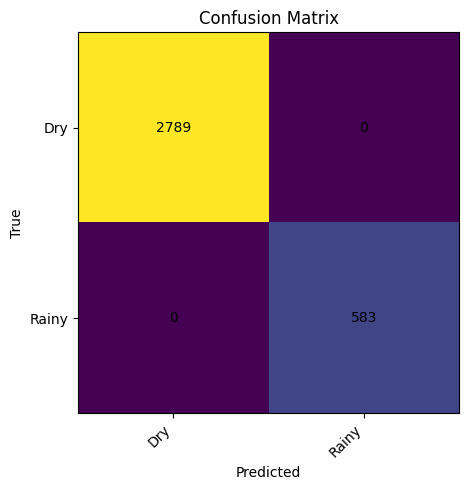

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt, numpy as np, os

preds = best_model.predict(X_val)
print(classification_report(y_val, preds))

labels = sorted(y_val.unique())
cm = confusion_matrix(y_val, preds, labels=labels)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45, ha='right')
plt.yticks(ticks=range(len(labels)), labels=labels)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/confusion_matrix.png", dpi=150)
plt.show()

## 9) Save Artifacts

In [34]:
import joblib, json, pandas as pd, os
os.makedirs("artifacts", exist_ok=True)
joblib.dump(best_model, "artifacts/weather_conditions_model.pkl")

report = {
    "best_baseline": best_name,
    "best_params": grid.best_params_,
    "val_accuracy": float((preds==y_val).mean()),
    "timestamp": str(pd.Timestamp.now())
}
with open("artifacts/report.json", "w") as f:
    json.dump(report, f, indent=2)
print("Saved artifacts in /artifacts")

Saved artifacts in /artifacts
